# 01 Data Exploration

This notebook performs the initial exploratory data analysis (EDA) for the parking transaction dataset collected from three parking sites in 2025.

The objectives of this notebook are to:

- load and combine the three parking transaction files
- inspect the structure of the dataset
- identify missing values and duplicates
- explore temporal transaction patterns
- examine payment and duration-related distributions
- understand the nature of the dataset before preprocessing

## Import Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


## Load and Combine Site Files

In [ ]:
site_a_filepath = r"data/processed/parking_transactions_cleaned.csv"
site_b_filepath = r"data/processed/parking_transactions_cleaned.csv"
site_c_filepath = r"data/processed/parking_transactions_cleaned.csv"

site_a = pd.read_csv(site_a_filepath,na_values=["\\N"])
site_b = pd.read_csv(site_b_filepath,na_values=["\\N"])
site_c = pd.read_csv(site_c_filepath,na_values=["\\N"])

In [68]:

site_a["site"] = "Site A"
site_b["site"] = "Site B"
site_c["site"] = "Site C"

df = pd.concat([site_a, site_b, site_c], ignore_index=True)

print("Site A shape:", site_a.shape)
print("Site B shape:", site_b.shape)
print("Site C shape:", site_c.shape)
print("Combined shape:", df.shape)


Site A shape: (11584, 22)
Site B shape: (41337, 22)
Site C shape: (34520, 22)
Combined shape: (87441, 22)


## Preview Data

In [ ]:

df.head()


,id,loc_id,reference_id,device_id_in,device_id_out,transaction_dateIn,transaction_dateOut,card_no,amount,response_code,card_type,RRN,STAN,approval_code,sync_flag,ss_sync_date,hq_sync_date,batch_id,user_category,coupon_id,sst_amount,site
0,43525,42,42202511756075005,NaN,X01,2025-01-01 07:48:30,2025-01-01 07:55:26,2783752655,0.0,NaN,TNG,NaN,NaN,NaN,1,2025-01-01 07:56:00,2025-01-17 03:01:11,488,1,NaN,NaN,Site A
1,43530,42,422025111449019504,NaN,X01,2025-01-01 14:41:08,2025-01-01 14:42:48,1882361935,0.0,NaN,TNG,NaN,NaN,NaN,1,2025-01-01 14:49:00,2025-01-17 03:01:11,488,1,NaN,NaN,Site A
2,43531,42,422025111514034412,NaN,X01,2025-01-01 14:38:23,2025-01-01 15:10:48,2165653295,0.0,NaN,TNG,NaN,NaN,NaN,1,2025-01-01 15:14:00,2025-01-17 03:01:11,488,1,NaN,NaN,Site A
3,43532,42,422025111521010598,NaN,X01,2025-01-01 10:16:10,2025-01-01 15:20:36,2783752655,10.0,NaN,TNG,NaN,NaN,NaN,1,2025-01-01 15:21:00,2025-01-17 03:01:12,488,1,NaN,NaN,Site A
4,43533,42,42202511177047676,NaN,X01,2025-01-01 16:36:45,2025-01-01 17:03:01,1795549711,0.0,NaN,TNG,NaN,NaN,NaN,1,2025-01-01 17:07:00,2025-01-17 03:01:12,488,1,NaN,NaN,Site A


## Dataset Structure

In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87441 entries, 0 to 87440
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   87441 non-null  int64  
 1   loc_id               87441 non-null  int64  
 2   reference_id         87441 non-null  object 
 3   device_id_in         35609 non-null  float64
 4   device_id_out        87441 non-null  object 
 5   transaction_dateIn   87441 non-null  object 
 6   transaction_dateOut  87441 non-null  object 
 7   card_no              87441 non-null  object 
 8   amount               87441 non-null  float64
 9   response_code        6683 non-null   float64
 10  card_type            87440 non-null  object 
 11  RRN                  6646 non-null   object 
 12  STAN                 6646 non-null   float64
 13  approval_code        6646 non-null   object 
 14  sync_flag            87441 non-null  int64  
 15  ss_sync_date         87441 non-null 

## Column Names

In [ ]:

df.columns.tolist()


['id',
 'loc_id',
 'reference_id',
 'device_id_in',
 'device_id_out',
 'transaction_dateIn',
 'transaction_dateOut',
 'card_no',
 'amount',
 'response_code',
 'card_type',
 'RRN',
 'STAN',
 'approval_code',
 'sync_flag',
 'ss_sync_date',
 'hq_sync_date',
 'batch_id',
 'user_category',
 'coupon_id',
 'sst_amount',
 'site']

## Missing Values Summary

In [71]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="Missing Percentage", ascending=False)

missing_summary


,Missing Count,Missing Percentage
sst_amount,87441,100.000000
coupon_id,87441,100.000000
approval_code,80795,92.399446
STAN,80795,92.399446
RRN,80795,92.399446
response_code,80758,92.357132
device_id_in,51832,59.276541
card_type,1,0.001144
transaction_dateIn,0,0.000000
loc_id,0,0.000000


## Duplicate Check

In [72]:

print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


## Transaction Count by Site

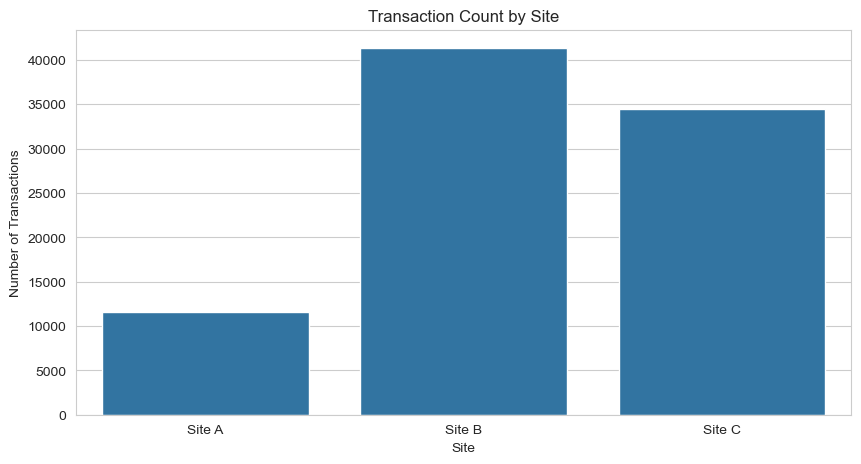

In [73]:
sns.countplot(data=df, x="site")
plt.title("Transaction Count by Site")
plt.xlabel("Site")
plt.ylabel("Number of Transactions")
plt.show()

## Derive Analytical Columns

Before exploring distributions, the datetime columns are parsed and the derived analytical columns used throughout the rest of the notebook are created: parking duration and the entry time-parts (hour, day name, month).

In [74]:
df["transaction_dateIn"] = pd.to_datetime(df["transaction_dateIn"], errors="coerce")
df["transaction_dateOut"] = pd.to_datetime(df["transaction_dateOut"], errors="coerce")
df["ss_sync_date"] = pd.to_datetime(df["ss_sync_date"], errors="coerce")
df["hq_sync_date"] = pd.to_datetime(df["hq_sync_date"], errors="coerce")

## Check Date Range

In [75]:
print("Earliest transaction_dateIn:", df["transaction_dateIn"].min())
print("Latest transaction_dateIn:", df["transaction_dateIn"].max())
print("Earliest transaction_dateOut:", df["transaction_dateOut"].min())
print("Latest transaction_dateOut:", df["transaction_dateOut"].max())

Earliest transaction_dateIn: 2025-01-01 03:47:54
Latest transaction_dateIn: 2025-12-31 20:24:19
Earliest transaction_dateOut: 2025-01-01 07:55:26
Latest transaction_dateOut: 2025-12-31 20:37:58


In [76]:
df["parking_duration_minutes"] = (
    (df["transaction_dateOut"] - df["transaction_dateIn"]).dt.total_seconds() / 60
)

df["entry_hour"] = df["transaction_dateIn"].dt.hour
df["entry_day_name"] = df["transaction_dateIn"].dt.day_name()
df["entry_month"] = df["transaction_dateIn"].dt.month
df["entry_date"] = df["transaction_dateIn"].dt.date

In [ ]:
all_dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")

coverage_records = []
missing_date_records = []

for site in sorted(daily_df["site"].unique()):
    site_dates = set(daily_df.loc[daily_df["site"] == site, "entry_date"])
    missing_dates = [date for date in all_dates if date not in site_dates]

    coverage_records.append({
        "site": site,
        "recorded_days": len(site_dates),
        "missing_days": len(missing_dates),
        "first_recorded_date": min(site_dates),
        "last_recorded_date": max(site_dates)
    })

    for date in missing_dates:
        missing_date_records.append({
            "site": site,
            "missing_date": date
        })

coverage_summary = pd.DataFrame(coverage_records)
missing_dates_df = pd.DataFrame(missing_date_records)

coverage_summary

## Explore Parking Duration

In [36]:
df["parking_duration_minutes"].describe()

count    87441.000000
mean       567.561090
std       1154.841381
min         -3.216667
25%        156.816667
50%        517.450000
75%        723.183333
max      90143.666667
Name: parking_duration_minutes, dtype: float64

In [38]:
negative_duration_count = (df["parking_duration_minutes"] < 0).sum()
print("Number of negative parking durations:", negative_duration_count)

Number of negative parking durations: 1


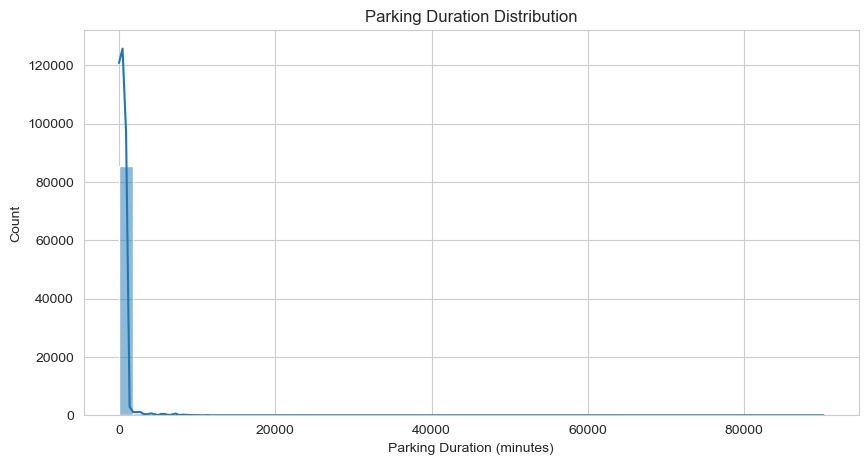

In [39]:
sns.histplot(df["parking_duration_minutes"], bins=50, kde=True)
plt.title("Parking Duration Distribution")
plt.xlabel("Parking Duration (minutes)")
plt.show()

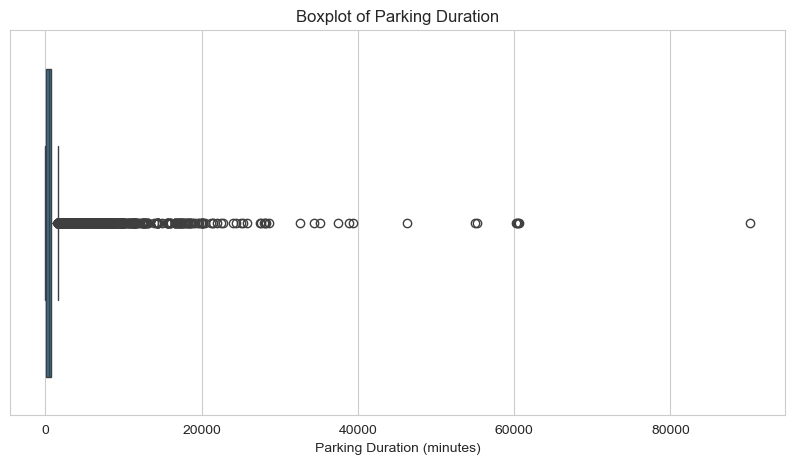

In [40]:
sns.boxplot(x=df["parking_duration_minutes"])
plt.title("Boxplot of Parking Duration")
plt.xlabel("Parking Duration (minutes)")
plt.show()

## Explore Temporal Patterns

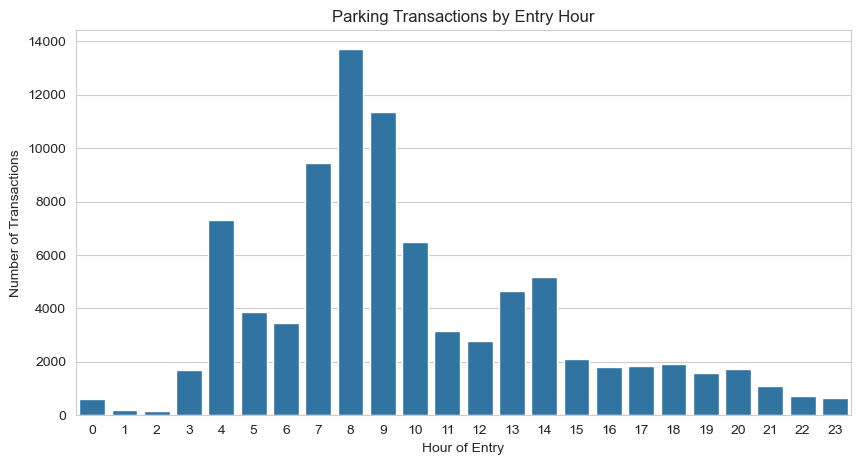

In [ ]:

sns.countplot(data=df, x="entry_hour")
plt.title("Parking Transactions by Entry Hour")
plt.xlabel("Hour of Entry")
plt.ylabel("Number of Transactions")
plt.show()


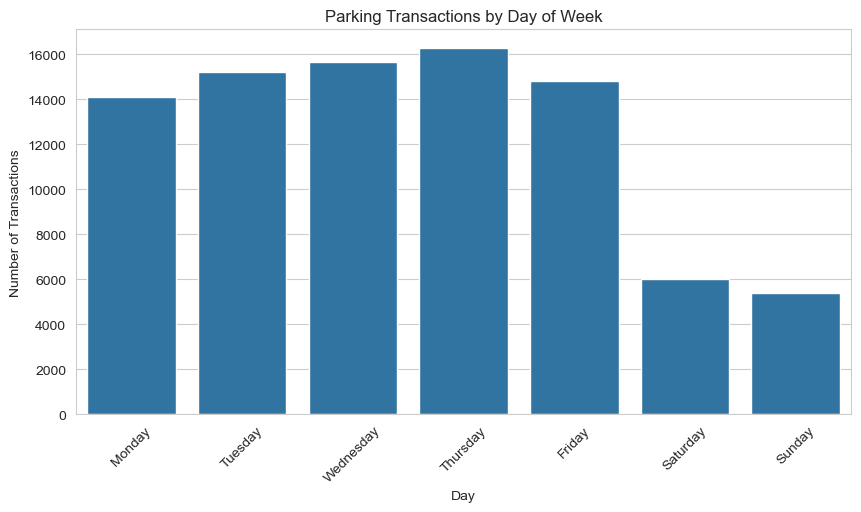

In [ ]:

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.countplot(data=df, x="entry_day_name", order=order)
plt.title("Parking Transactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()


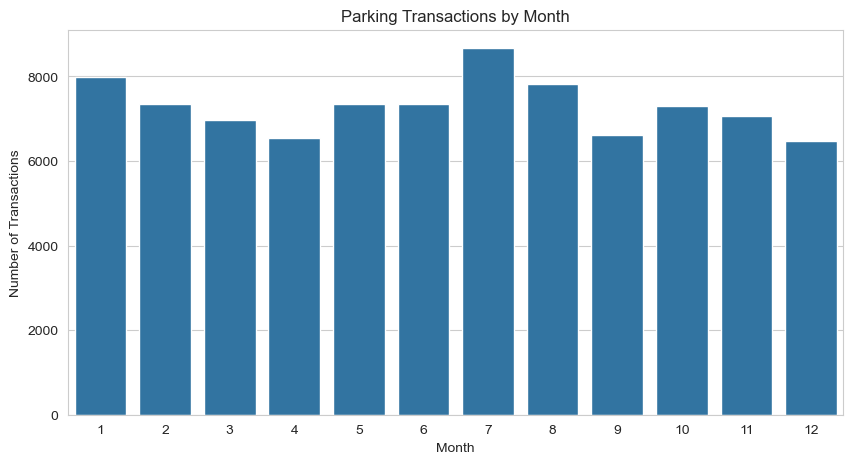

In [43]:
sns.countplot(data=df, x="entry_month")
plt.title("Parking Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

## Explore Parking Amount

In [44]:
df["amount"].describe()

count    87441.000000
mean         6.524073
std          8.340832
min          0.000000
25%          0.000000
50%          4.000000
75%         12.000000
max        238.000000
Name: amount, dtype: float64

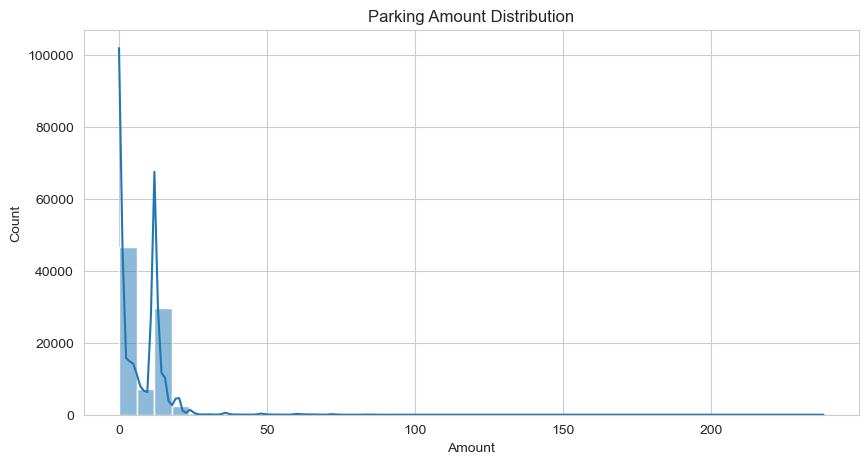

In [45]:
sns.histplot(df["amount"], bins=40, kde=True)
plt.title("Parking Amount Distribution")
plt.xlabel("Amount")
plt.show()

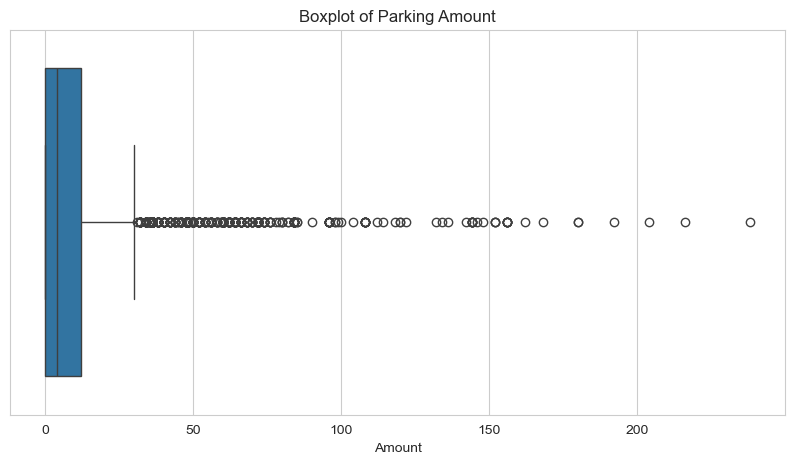

In [46]:
sns.boxplot(x=df["amount"])
plt.title("Boxplot of Parking Amount")
plt.xlabel("Amount")
plt.show()

## Payment Type and Per-Site Comparison

In [47]:
df["card_type"].value_counts(dropna=False)

card_type
TNG           51832
BigR Card     28926
VISA           4556
MASTERCARD     2126
NaN               1
Name: count, dtype: int64

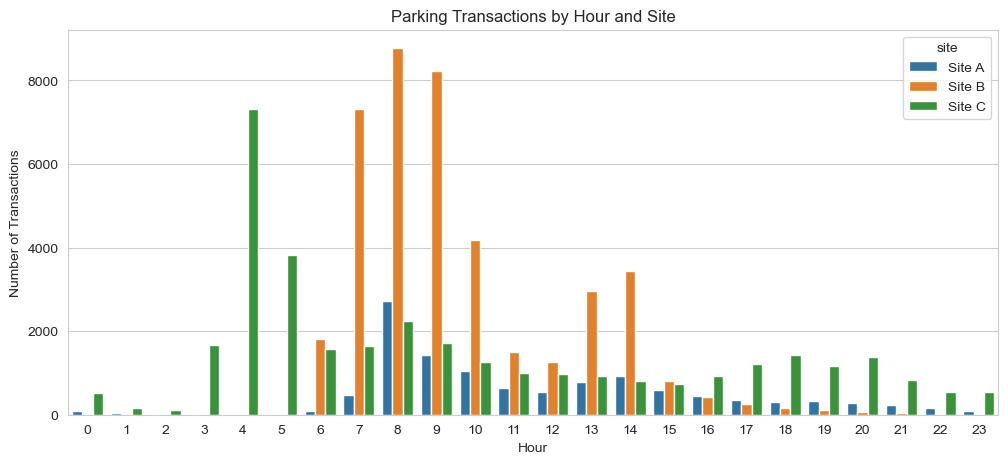

In [ ]:

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="entry_hour", hue="site")
plt.title("Parking Transactions by Hour and Site")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()


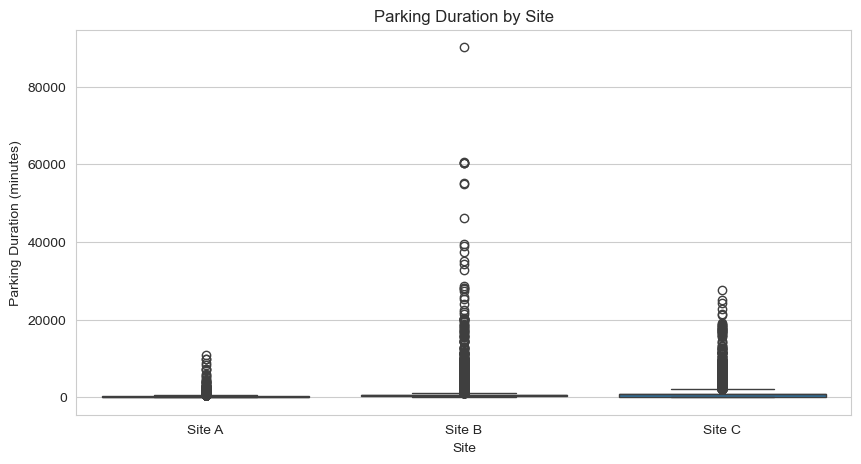

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="site", y="parking_duration_minutes")
plt.title("Parking Duration by Site")
plt.xlabel("Site")
plt.ylabel("Parking Duration (minutes)")
plt.show()

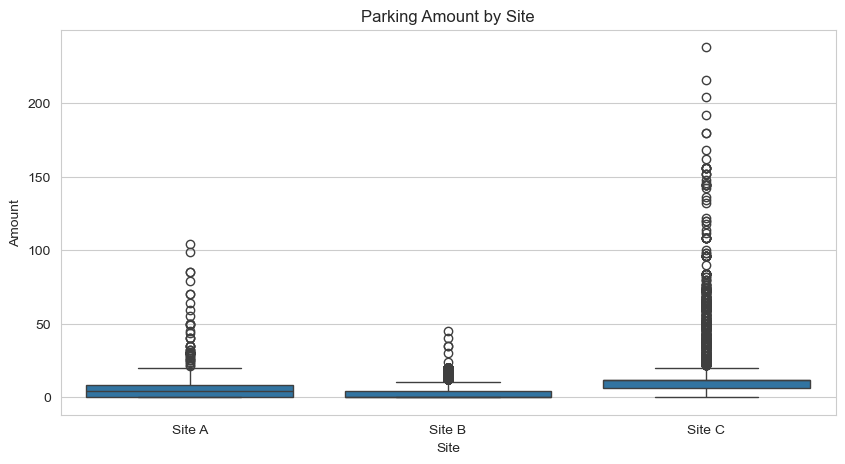

In [53]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="site", y="amount")
plt.title("Parking Amount by Site")
plt.xlabel("Site")
plt.ylabel("Amount")
plt.show()

In [ ]:
df.groupby("site")[["amount", "parking_duration_minutes"]].describe()